# 08 — Cost & latency (E6, M5)

Story notebook for Milestone 5 (PLAN.md §3 E6, §8 G4). Thin (PLAN.md §6): every table and figure below was already produced by earlier tasks — the retrieval cost/latency harness (T5.3), the API-client token/latency telemetry and pricing config (T5.2/T5.4), the end-to-end live-latency harness (T5.5), and the joined quality-vs-cost Pareto table (T5.6). This notebook only imports from `src/`, reads already-committed CSVs and a already-rendered PNG, and tells the story — it makes **no API calls and builds no indexes**, so re-running it top to bottom costs nothing and touches no network.

In [1]:
import pandas as pd
from IPython.display import Image, display

from cragb.utils.io import resolve_path

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)

## Retrieval cost & latency: BM25 vs. dense (T5.3)

Index build time & on-disk size, plus per-query search throughput (QPS) and p50/p90/p95 latency — measured over all 60 CRAGB v1 questions with warm-up discarded (`cragb.utils.timing.time_calls`), for the exact BM25/dense configuration whose Recall@k is already reported in `retrieval_eval_v1.csv` (T3.5/T3.6).

In [2]:
retrieval_cost_latency = pd.read_csv(resolve_path("results/tables/retrieval_cost_latency_v1.csv"))
display(retrieval_cost_latency)

,retriever,n_chunks,build_seconds,index_bytes,peak_rss_mb,peak_vram_mb,device,n_queries,qps,latency_p50_ms,latency_p90_ms,latency_p95_ms,latency_mean_ms
0,bm25,200000,5.422,75024680,1046.0,0.0,NaN,180,1.20,845.41,1038.20,1089.65,832.76
1,dense,200000,459.578,308889574,2022.9,729.0,cuda,180,21.31,46.76,49.21,49.82,46.92


## Answer-generation cost: $/query per arm (T5.2/T5.4)

Token accounting and $/query for the three RQ0/RQ1 answer-generation arms (closed-book, RAG-small, RAG-large), at the Groq per-model rates snapshotted in `configs/pricing.yaml`. All three arms' token counts are recovered from the existing disk cache rather than a fresh API call (`cragb.eval.cost_model.reissue_transcripts_for_tokens`) — see PLAN.md §14.5 for why every row is `is_estimated=True`: the 180 T4b.2 transcripts predate the usage-telemetry sidecar T5.2 added, so their real token counts are unrecoverable and the reported figures use a documented chars-per-token estimate instead.

In [3]:
answer_cost = pd.read_csv(resolve_path("results/tables/answer_cost_v1.csv"))
display(answer_cost)

,arm,model,n_questions,mean_prompt_tokens,mean_completion_tokens,mean_usd_per_query,usd_per_query_ci_lo,usd_per_query_ci_hi,total_usd,is_estimated
0,closed_book,openai/gpt-oss-20b,60,375.55,34.583333,0.000039,0.000035,0.000043,0.002312,True
1,rag_small,openai/gpt-oss-20b,60,809.70,56.516667,0.000078,0.000074,0.000081,0.004661,True
2,rag_large,openai/gpt-oss-120b,60,809.70,53.716667,0.000154,0.000147,0.000160,0.009221,True


## End-to-end latency: live, cache-bypassed (T5.5)

Retrieval + context assembly + generation, wall-clock, per arm — the number a user would actually feel. Every call here bypassed the disk cache on both read and write (`GroqClient.complete_with_usage(..., bypass_cache=True)`), over a fixed, seeded 15-question sample stratified across CRAGB's taxonomy types (`cragb.eval.run_cost_latency.stratified_question_sample`). `cache_bypassed=True` in every row below confirms the bypass actually worked, rather than silently timing cache hits. **Read as a single-client, sequential, free-tier measurement** — Groq's shared free tier is not a latency SLA, and these are not production numbers.

In [4]:
e2e_latency = pd.read_csv(resolve_path("results/tables/e2e_latency_v1.csv"))
display(e2e_latency)

,arm,model,n,retrieval_ms_p50,generate_ms_p50,e2e_ms_p50,e2e_ms_p95,e2e_ms_mean,run_timestamp,cache_bypassed
0,closed_book,openai/gpt-oss-20b,15,0.0000,3473.8373,3473.8517,4503.01748,2607.804527,2026-08-23T12:35:09.702647+00:00,True
1,rag_small,openai/gpt-oss-20b,15,706.7299,10254.6866,10922.8737,13873.76015,10538.061280,2026-08-23T12:35:56.571225+00:00,True
2,rag_large,openai/gpt-oss-120b,15,735.5030,8581.0245,9207.3499,13733.23050,7892.097760,2026-08-23T12:38:34.566794+00:00,True


## Quality vs. cost: the joined Pareto table + figure (T5.6, report figure #4)

One row per configuration — the three answer-generation arms joined against their judge-scored quality (M4b) and measured cost/latency above, plus BM25/dense retrieval as a companion section (`component` column) on their own natural quality/cost axes (Recall@k vs. per-query search latency — retrieval has no $/query of its own). `on_frontier` marks the non-dominated configurations within each component; see `cragb.eval.pareto` for why the two components get separate frontiers rather than one shared comparison.

In [5]:
cost_quality = pd.read_csv(resolve_path("results/tables/cost_quality_v1.csv"))
display(cost_quality)

,component,config,arm,model,n,quality_mean,quality_ci_lo,quality_ci_hi,usd_per_query,usd_per_query_ci_lo,usd_per_query_ci_hi,e2e_ms_p50,e2e_ms_p95,on_frontier,retriever,latency_ms_p50
0,answer_generation,closed_book,closed_book,openai/gpt-oss-20b,60,1.516667,1.233333,1.850000,0.000039,0.000035,0.000043,3473.8517,4503.01748,True,NaN,NaN
1,answer_generation,rag_small,rag_small,openai/gpt-oss-20b,60,3.666667,3.300000,4.016667,0.000078,0.000074,0.000081,10922.8737,13873.76015,True,NaN,NaN
2,answer_generation,rag_large,rag_large,openai/gpt-oss-120b,60,3.766667,3.400000,4.100000,0.000154,0.000147,0.000160,9207.3499,13733.23050,True,NaN,NaN
3,retrieval,bm25,NaN,NaN,58,0.260243,0.230642,0.291382,NaN,NaN,NaN,NaN,NaN,True,bm25,845.41
4,retrieval,dense,NaN,NaN,58,0.259141,0.223666,0.299756,NaN,NaN,NaN,NaN,NaN,True,dense,46.76


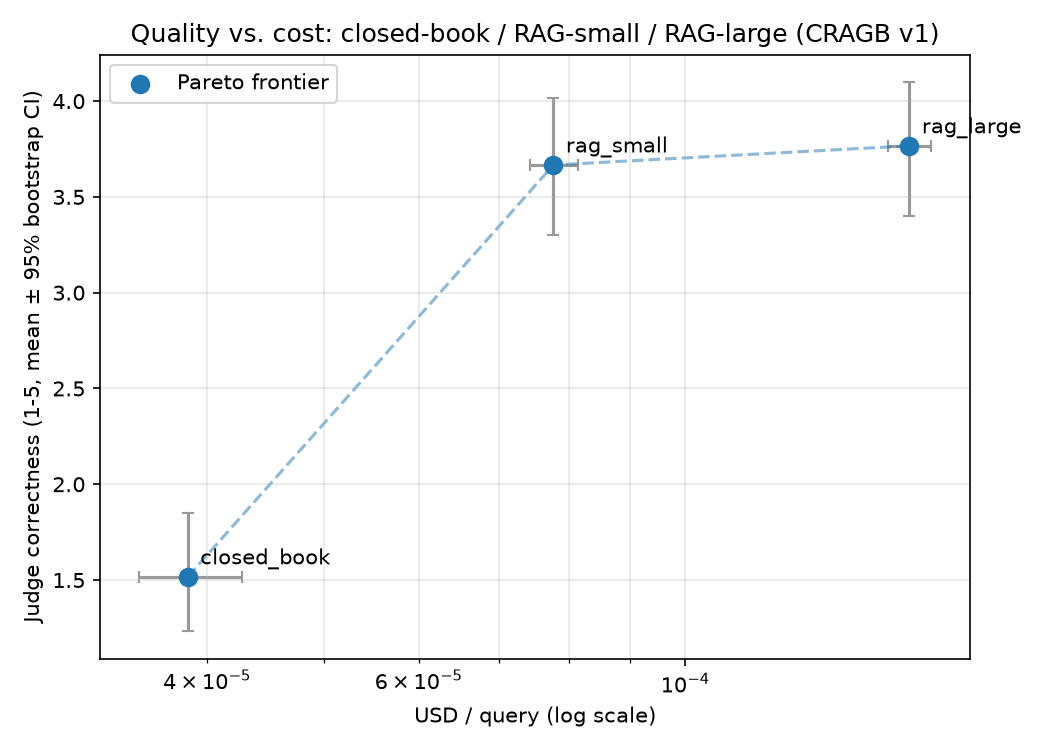

In [6]:
display(Image(filename=str(resolve_path("reports/figures/quality_vs_cost_pareto_v1.png"))))

## Summary

- **Retrieval (T5.3):** BM25 and dense sit on their own Pareto frontier — neither dominates. BM25 is the faster *build*; dense is dramatically faster to *query* once built (an exact FAISS flat index on GPU vs. pure-Python/NumPy exact scoring), at a small Recall@5 cost. Which one wins depends on whether the bottleneck is index-build time or query-serving latency.
- **$/query (T5.2/T5.4):** closed-book is far cheaper per query than either RAG arm (no retrieved context to send), and RAG-large costs roughly what its per-token pricing predicts relative to RAG-small — the RQ1 prompt-token control (`answer_cost_v1.csv`'s `mean_prompt_tokens`) held essentially exactly, confirming the two arms differ only in model, not in what they were shown.
- **End-to-end latency (T5.5):** grounding adds real, felt latency over closed-book — not just an API cost line item.
- **Quality vs. cost (T5.6, figure #4):** the headline finding. RAG-small → RAG-large's judge-correctness error bars visibly overlap in the figure above, at roughly double the $/query — the 120B upgrade is **not** a statistically justified win on this benchmark, while closed-book → RAG-small is a large, non-overlapping jump. Retrieval, not model scale, is where this pipeline's quality comes from.


## What this means for the fine-tuning decision (PLAN.md §10 go/no-go)

§10's go/no-go asks whether a fine-tuning pilot should proceed on the answer-generation path, or the fallback (fine-tune the retriever/embedding instead) should trigger. This milestone's evidence points the same way twice: (1) scaling the *generator* 20B → 120B bought no statistically significant quality gain at roughly double the cost and no latency improvement (T5.6's figure), so spending the second half's limited GPU-hour budget teaching a small generator to imitate a bigger one is a weak bet — there is no large model advantage on this benchmark to distill. (2) The actual generation-vs-retrieval quality gap (RQ0, closed-book → RAG-small) is large, and §10's target behaviours for fine-tuning — citation/format compliance, correct abstention, grounding faithfulness — are properties of *how the small model uses retrieved context*, not of model scale. That keeps §10's plan on its stated course (QLoRA on the small generator, targeting grounding discipline, not raw world knowledge) rather than triggering the retriever/embedding fallback — this milestone found no evidence that retrieval itself is the weak link (BM25 and dense are both viable, RQ2's Recall@k gap is not the story here); the weak link this milestone actually surfaces is the model's use of what it's given, which is exactly what §10 already proposes to fine-tune.